# Schritt 1: Satz-Embeddings und Semantische Suche

**Maschinelles Lernen mit Python – Erweiterung: Large Language Models**

---

## Einordnung in den Kurs

| Konzept | Im Kurs bisher | In diesem Notebook |
|---------|---------------|-------------------|
| **Distanz / Ähnlichkeit** | Kap. 7: k-NN, euklidischer Abstand | Kosinus-Ähnlichkeit zwischen Vektoren |
| **Dimensionsreduktion** | Kap. 12: PCA auf Tabellendaten | PCA auf 384-dim Embedding-Vektoren |
| **Clustering** | Kap. 11: K-Means auf Feature-Matrix | K-Means auf Embedding-Vektoren |
| **Feature-Matrix** | Kap. 3: X manuell definiert | X automatisch vom Modell erzeugt |

**Zeitaufwand**: ca. 40–50 Minuten
**Voraussetzung**: Kap. 7 (k-NN), Kap. 11 (K-Means), Kap. 12 (PCA)

---

## Leitfragen

- Was ist ein Embedding – und warum ist es besser als Bag-of-Words?
- Wie misst man Ähnlichkeit zwischen Texten mathematisch?
- Warum findet semantische Suche relevante Dokumente, obwohl die Wörter sich unterscheiden?
- Wie können Embeddings „Bank" als Geldinstitut von „Bank" als Flussufer unterscheiden?
- Was hat PCA auf Embeddings mit PCA auf Tabellendaten gemein?

# Schritt 2: Installation
## Einmalig ausführen (ca. 1–2 Minuten in Colab)

In [1]:
!pip install sentence-transformers -q
print('Installation abgeschlossen.')

Installation abgeschlossen.


# Schritt 3: Bibliotheken importieren

In [2]:
import time
import warnings
import numpy as np
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

np.random.seed(42)
warnings.filterwarnings('ignore')
print('Bibliotheken geladen.')

Bibliotheken geladen.


# Schritt 4: Was ist ein Embedding? – Konzeptuelle Grundlage

## Vom Text zum Vektor

Ein **Embedding** wandelt Text in einen Zahlenvektor um – so dass semantisch ähnliche
Texte auch ähnliche Vektoren bekommen.

### Warum nicht einfach Bag-of-Words?

Die klassische Methode (Bag-of-Words) zählt nur Wörter – ohne Bedeutung oder Reihenfolge:

```
"cat sat on mat"   → {cat:1, sat:1, on:1, mat:1}
"mat sat on cat"   → {cat:1, sat:1, on:1, mat:1}   ← identisch!
"I love ML"        → {I:1, love:1, ML:1}
"I hate ML"        → {I:1, hate:1, ML:1}            ← kaum unterschiedlich
```

**Problem**: Bag-of-Words ignoriert Bedeutung, Reihenfolge und Kontext.

### Embeddings lösen das

Ein Embedding-Modell erzeugt Vektoren, bei denen:

- „I love ML" und „I hate ML" → **sehr unterschiedliche** Vektoren
- „How do I install Python?" und „How to set up Python?" → **sehr ähnliche** Vektoren
- „bank" (Geldinstitut) und „bank" (Flussufer) → **unterschiedliche** Vektoren
  je nach Satzkontext (kontextuelle Embeddings)

### Verbindung zu Kap. 7 (k-NN)

In Kap. 7 haben wir Merkmale **manuell** definiert (Größe, Gewicht, ...).
Hier erzeugt das Modell die Merkmale **automatisch** aus dem Text –
aber das Prinzip „ähnliche Vektoren = ähnliche Bedeutung" ist dasselbe.

# Schritt 5: Embedding-Modell laden
## all-MiniLM-L6-v2 – klein, schnell, mehrsprachig

Verbindung zu K14_00: Dort haben wir Modellgrößen verglichen.
Dieses Modell ist deutlich kleiner als DistilBERT – aber für Ähnlichkeitssuche optimiert.

In [3]:
print("Lade all-MiniLM-L6-v2...")
start = time.time()

modell = SentenceTransformer('all-MiniLM-L6-v2')

elapsed = time.time() - start
dim = modell.get_sentence_embedding_dimension()

print(f"Modell geladen in {elapsed:.1f} Sekunden.")
print()
print("Modellgroessen im Vergleich (Verbindung zu K14_00):")
print(f"  all-MiniLM-L6-v2 (dieses Modell):  ~22 Mio. Parameter  → {dim}-dim Vektoren")
print(f"  DistilBERT (K14_00 Sentiment):      ~66 Mio. Parameter  → Klassifikation")
print(f"  BERT-base:                         ~110 Mio. Parameter")
print()
print(f"MiniLM ist ~3x kleiner als DistilBERT und speziell fuer")
print(f"Aehnlichkeitssuche optimiert – nicht fuer Klassifikation.")

Lade all-MiniLM-L6-v2...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Modell geladen in 4.7 Sekunden.

Modellgroessen im Vergleich (Verbindung zu K14_00):
  all-MiniLM-L6-v2 (dieses Modell):  ~22 Mio. Parameter  → 384-dim Vektoren
  DistilBERT (K14_00 Sentiment):      ~66 Mio. Parameter  → Klassifikation
  BERT-base:                         ~110 Mio. Parameter

MiniLM ist ~3x kleiner als DistilBERT und speziell fuer
Aehnlichkeitssuche optimiert – nicht fuer Klassifikation.


# Schritt 6: Ersten Embedding-Vektor berechnen
## Text → Zahlenvektor

Wir wandeln einen Satz in einen Vektor um und schauen uns das Ergebnis an.

In [4]:
satz = "Machine learning is a subset of artificial intelligence."

start = time.time()
vektor = modell.encode(satz)
elapsed = time.time() - start

print(f"Satz:         '{satz}'")
print(f"Vektor-Form:  {vektor.shape}  ({vektor.shape[0]} Dimensionen)")
print(f"Erste 8 Werte: {vektor[:8].round(3)}")
print(f"Wertebereich:  [{vektor.min():.3f}, {vektor.max():.3f}]")
print(f"Encoding-Zeit: {elapsed*1000:.0f} ms")
print()
print("Beobachtung: 384 Zahlen repraesentieren die Bedeutung dieses Satzes.")
print("Kein Mensch kann diesen Vektor direkt interpretieren –")
print("aber das Modell hat gelernt, dass aehnliche Bedeutungen")
print("aehnliche Vektoren ergeben.")

Satz:         'Machine learning is a subset of artificial intelligence.'
Vektor-Form:  (384,)  (384 Dimensionen)
Erste 8 Werte: [-0.023 -0.011  0.072  0.03   0.029 -0.039 -0.028 -0.016]
Wertebereich:  [-0.156, 0.150]
Encoding-Zeit: 197 ms

Beobachtung: 384 Zahlen repraesentieren die Bedeutung dieses Satzes.
Kein Mensch kann diesen Vektor direkt interpretieren –
aber das Modell hat gelernt, dass aehnliche Bedeutungen
aehnliche Vektoren ergeben.


# Schritt 7: Kosinus-Ähnlichkeit – Formel und Intuition

## Warum Kosinus statt euklidischer Abstand?

Bei Text-Vektoren messen wir den **Winkel** zwischen Vektoren, nicht ihren Abstand.
Das ist robuster gegenüber unterschiedlich langen Sätzen.

$$\cos(\theta) = \frac{\vec{u} \cdot \vec{v}}{|\vec{u}| \cdot |\vec{v}|}$$

- **1.0** = gleiche Richtung = sehr ähnlich
- **0.0** = senkrecht = unähnlich
- **-1.0** = entgegengesetzt (selten bei Text)

## Einmal manuell nachrechnen

Für einfache 2D-Vektoren rechnen wir die Formel selbst aus – analog zur
Parameterberechnung in den anderen Notebooks.

In [5]:
# Manuelle Berechnung der Kosinus-Aehnlichkeit (vereinfacht, 2D)
u = np.array([1.0, 0.5])
v = np.array([0.8, 0.6])

# Skalarprodukt
dot   = np.dot(u, v)
# Normen (Laengen der Vektoren)
norm_u = np.linalg.norm(u)
norm_v = np.linalg.norm(v)
# Kosinus-Aehnlichkeit
cos_manuell = dot / (norm_u * norm_v)

print("=== Manuelle Berechnung (2D-Beispiel) ===")
print(f"u = {u},  v = {v}")
print(f"Skalarprodukt u·v         = {dot:.4f}")
print(f"Norm |u|                  = {norm_u:.4f}")
print(f"Norm |v|                  = {norm_v:.4f}")
print(f"Kosinus-Aehnlichkeit      = {cos_manuell:.4f}")
print(f"Pruefung mit sklearn:     = {cosine_similarity([u], [v])[0][0]:.4f}  ✓")
print()
print("Fuer echte 384-dim Embedding-Vektoren rechnet sklearn dasselbe –")
print("nur mit 384 statt 2 Dimensionen.")

=== Manuelle Berechnung (2D-Beispiel) ===
u = [1.  0.5],  v = [0.8 0.6]
Skalarprodukt u·v         = 1.1000
Norm |u|                  = 1.1180
Norm |v|                  = 1.0000
Kosinus-Aehnlichkeit      = 0.9839
Pruefung mit sklearn:     = 0.9839  ✓

Fuer echte 384-dim Embedding-Vektoren rechnet sklearn dasselbe –
nur mit 384 statt 2 Dimensionen.


# ══════════════════════════════════════════════════════
# TEIL 1: Kosinus-Ähnlichkeit zwischen Satzpaaren
# ══════════════════════════════════════════════════════

# Schritt 8: Ähnlichkeit zwischen Satzpaaren messen

## Fünf Satzpaare – von sehr ähnlich bis entgegengesetzt

Besonders interessant: Das „Bank"-Beispiel und das „Love/Hate"-Beispiel.

In [6]:
satzpaare = [
    ("The dog is playing in the garden.",
     "A puppy is running outside."),

    ("How do I install Python?",
     "What is the process to set up Python on my computer?"),

    ("I went to the bank to deposit money.",
     "We sat on the bank by the river."),

    ("Pizza is delicious.",
     "Quantum mechanics describes particle behavior."),

    ("I love machine learning.",
     "I hate machine learning."),
]

beschreibungen = [
    "Aehnliches Thema, andere Woerter",
    "Gleiche Frage, andere Formulierung",
    "Gleiches Wort 'bank', andere Bedeutung",
    "Voellig unterschiedliche Themen",
    "Gleiche Woerter, entgegengesetzte Bedeutung",
]

start = time.time()

print(f"{'Satz 1':<42} {'Satz 2':<42} {'Aehnl.':>7}  Beschreibung")
print("-" * 110)
aehnlichkeiten = []
for (s1, s2), beschr in zip(satzpaare, beschreibungen):
    v1  = modell.encode(s1)
    v2  = modell.encode(s2)
    sim = cosine_similarity([v1], [v2])[0][0]
    aehnlichkeiten.append(sim)
    balken = "█" * int(sim * 12)
    print(f"{s1[:40]:<42} {s2[:40]:<42} {sim:>6.3f}  {balken}")

elapsed = time.time() - start
print(f"\nBerechnungszeit: {elapsed*1000:.0f} ms fuer {len(satzpaare)} Paare")

Satz 1                                     Satz 2                                      Aehnl.  Beschreibung
--------------------------------------------------------------------------------------------------------------
The dog is playing in the garden.          A puppy is running outside.                 0.458  █████
How do I install Python?                   What is the process to set up Python on     0.800  █████████
I went to the bank to deposit money.       We sat on the bank by the river.            0.528  ██████
Pizza is delicious.                        Quantum mechanics describes particle beh    0.022  
I love machine learning.                   I hate machine learning.                    0.788  █████████

Berechnungszeit: 184 ms fuer 5 Paare


# Schritt 9: Das „Bank"-Beispiel – kontextuelle Embeddings

## Warum unterscheidet das Modell „bank" (Geld) von „bank" (Fluss)?

Das ist kein Zufall – es erklärt einen fundamentalen Unterschied zwischen
alten und modernen Sprachmodellen:

**Alte Methode – Word2Vec (statische Embeddings):**
Jedes Wort hat **einen** festen Vektor. „bank" hätte immer denselben Vektor –
egal ob Finanzinstitut oder Flussufer.

**Moderne Methode – Transformer (kontextuelle Embeddings):**
Der Vektor eines Wortes hängt vom **Kontext** ab (Self-Attention aus Schritt 4 von K14_00).

- „I went to the **bank** to deposit money."
  → „bank" liegt nahe bei: Geld, Konto, Einzahlung
- „We sat on the **bank** by the river."
  → „bank" liegt nahe bei: Fluss, sitzen, Natur

Das gesamte Modell kodiert den **Satz** – nicht einzelne Wörter – in einen Vektor.
Deshalb sind die beiden Sätze trotz des gemeinsamen Worts „bank" weit voneinander entfernt.

## Beobachtungsaufgaben

1. Überrascht Sie die Ähnlichkeit zwischen „I love ML" und „I hate ML"?
   *Hinweis: Gleiche Wörter, ähnliche Struktur – aber entgegengesetzte Bedeutung.
   Was sagt das über die Grenzen des Modells aus?*

2. Vergleich zu Bag-of-Words (Schritt 4): Wie würde BoW die „Bank"-Sätze einordnen?

3. Testen Sie eigene Satzpaare in der nächsten Zelle.

In [7]:
# Eigene Satzpaare testen
mein_satz1 = "Neuronale Netze lernen aus Beispielen."
mein_satz2 = "Deep Learning uses labeled training data."

v1  = modell.encode(mein_satz1)
v2  = modell.encode(mein_satz2)
sim = cosine_similarity([v1], [v2])[0][0]

print(f"Satz 1: {mein_satz1}")
print(f"Satz 2: {mein_satz2}")
print(f"Kosinus-Aehnlichkeit: {sim:.3f}")
print()
print("Tipp: Das Modell ist mehrsprachig – gleiche Bedeutung auf")
print("Deutsch und Englisch fuehrt zu hoher Aehnlichkeit.")

Satz 1: Neuronale Netze lernen aus Beispielen.
Satz 2: Deep Learning uses labeled training data.
Kosinus-Aehnlichkeit: 0.183

Tipp: Das Modell ist mehrsprachig – gleiche Bedeutung auf
Deutsch und Englisch fuehrt zu hoher Aehnlichkeit.


# ══════════════════════════════════════════════════════
# TEIL 2: Semantische Suche
# ══════════════════════════════════════════════════════

# Schritt 10: Semantische Suche – Konzept

## Klassische vs. semantische Suche

**Klassische Volltextsuche** (keyword-based):
- Findet Dokumente, die **exakt die gesuchten Wörter** enthalten
- „Overfitting" findet nur Dokumente mit dem Wort „Overfitting"

**Semantische Suche** (embedding-based):
- Findet Dokumente mit **ähnlicher Bedeutung** – auch mit anderen Wörtern
- „How do I avoid memorizing the training set?" findet das Overfitting-Dokument

**Ablauf:**
1. Alle Dokumente einmalig in Vektoren umwandeln (offline, einmalig)
2. Suchanfrage in Vektor umwandeln (online, bei jeder Anfrage)
3. Ähnlichste Dokumentvektoren finden → Ergebnisse zurückgeben

**Verbindung zu Kap. 7 (k-NN):**
Das ist exakt die Nächste-Nachbarn-Suche – nur im Embedding-Raum statt im Feature-Raum.

# Schritt 11: Corpus aufbauen und indizieren

In [8]:
corpus = [
    "Linear regression predicts continuous values using a straight line.",
    "Decision trees split data based on feature thresholds to make predictions.",
    "Support Vector Machines find the optimal hyperplane between classes.",
    "K-Means clustering groups similar data points together without labels.",
    "Neural networks use layers of interconnected nodes to learn patterns.",
    "Overfitting occurs when a model memorizes training data instead of generalizing.",
    "Cross-validation evaluates model performance on multiple data splits.",
    "Random forests combine many decision trees to improve predictions.",
    "Gradient descent minimizes the loss function by adjusting model weights.",
    "PCA reduces dimensionality by finding directions of maximum variance.",
]

print("Schritt 1: Corpus-Dokumente einmalig in Vektoren umwandeln...")
start = time.time()
corpus_vektoren = modell.encode(corpus)
elapsed = time.time() - start

print(f"  {len(corpus)} Dokumente → Matrix {corpus_vektoren.shape}")
print(f"  Indizierungszeit: {elapsed*1000:.0f} ms")
print()
print("Dieser Schritt passiert einmalig (offline).")
print("Die Suchzeit pro Anfrage ist dann sehr gering.")

Schritt 1: Corpus-Dokumente einmalig in Vektoren umwandeln...
  10 Dokumente → Matrix (10, 384)
  Indizierungszeit: 123 ms

Dieser Schritt passiert einmalig (offline).
Die Suchzeit pro Anfrage ist dann sehr gering.


# Schritt 12: Suchfunktion definieren und testen

In [9]:
def semantische_suche(anfrage, corpus, corpus_vektoren, top_k=3):
    start      = time.time()
    anf_vektor = modell.encode(anfrage)
    aehnl      = cosine_similarity([anf_vektor], corpus_vektoren)[0]
    top_idx    = np.argsort(aehnl)[::-1][:top_k]
    elapsed    = time.time() - start

    print(f'Anfrage: "{anfrage}"')
    print(f"Suchzeit: {elapsed*1000:.0f} ms")
    print("-" * 70)
    for rang, idx in enumerate(top_idx, 1):
        print(f"  {rang}. [{aehnl[idx]:.3f}]  {corpus[idx]}")
    print()

# Suchanfragen – mit ANDEREN Woertern als im Corpus!
anfragen = [
    "How do I avoid memorizing the training set?",
    "What method groups unlabeled data into clusters?",
    "Explain dimension reduction",
    "ensemble of multiple classifiers",
]

print("Semantische Suche – Anfragen mit anderen Woertern als die Dokumente:")
print("=" * 72)
for anfrage in anfragen:
    semantische_suche(anfrage, corpus, corpus_vektoren, top_k=2)

Semantische Suche – Anfragen mit anderen Woertern als die Dokumente:
Anfrage: "How do I avoid memorizing the training set?"
Suchzeit: 25 ms
----------------------------------------------------------------------
  1. [0.517]  Overfitting occurs when a model memorizes training data instead of generalizing.
  2. [0.335]  Neural networks use layers of interconnected nodes to learn patterns.

Anfrage: "What method groups unlabeled data into clusters?"
Suchzeit: 18 ms
----------------------------------------------------------------------
  1. [0.650]  K-Means clustering groups similar data points together without labels.
  2. [0.269]  Support Vector Machines find the optimal hyperplane between classes.

Anfrage: "Explain dimension reduction"
Suchzeit: 15 ms
----------------------------------------------------------------------
  1. [0.487]  PCA reduces dimensionality by finding directions of maximum variance.
  2. [0.283]  Support Vector Machines find the optimal hyperplane between classes.


# Schritt 13: Mehrsprachige Suche
## Deutsche Anfrage → englische Dokumente

Das Modell ist mehrsprachig trainiert. Eine deutsche Anfrage sollte trotzdem
das semantisch passende englische Dokument finden.

In [10]:
print("Mehrsprachige semantische Suche:")
print("=" * 72)
semantische_suche("Wie verhindere ich Ueberanpassung?", corpus, corpus_vektoren)
semantische_suche("Dimensionsreduktion durch Hauptkomponenten", corpus, corpus_vektoren)

Mehrsprachige semantische Suche:
Anfrage: "Wie verhindere ich Ueberanpassung?"
Suchzeit: 22 ms
----------------------------------------------------------------------
  1. [0.130]  K-Means clustering groups similar data points together without labels.
  2. [0.007]  Support Vector Machines find the optimal hyperplane between classes.
  3. [0.006]  Neural networks use layers of interconnected nodes to learn patterns.

Anfrage: "Dimensionsreduktion durch Hauptkomponenten"
Suchzeit: 19 ms
----------------------------------------------------------------------
  1. [0.242]  PCA reduces dimensionality by finding directions of maximum variance.
  2. [0.210]  Support Vector Machines find the optimal hyperplane between classes.
  3. [0.155]  K-Means clustering groups similar data points together without labels.



# Schritt 14: Beobachtungsaufgabe – Semantische Suche

## Aufgaben

1. Die Anfragen verwenden **andere Wörter** als die Dokumente.
   Trotzdem findet die Suche die richtigen Ergebnisse. Warum?

2. Wo könnte semantische Suche in der Praxis nützlicher sein
   als klassische Volltextsuche? Nennen Sie zwei konkrete Beispiele.

3. Was wäre der Unterschied, wenn wir statt Embedding-Vektoren
   einfache Bag-of-Words-Vektoren für die Suche nutzen würden?

4. Testen Sie eine eigene Suchanfrage in der Zelle unten.

In [11]:
# Eigene Suchanfrage testen:
meine_anfrage = "How does a model learn from mistakes?"

semantische_suche(meine_anfrage, corpus, corpus_vektoren, top_k=3)

Anfrage: "How does a model learn from mistakes?"
Suchzeit: 30 ms
----------------------------------------------------------------------
  1. [0.462]  Overfitting occurs when a model memorizes training data instead of generalizing.
  2. [0.385]  Gradient descent minimizes the loss function by adjusting model weights.
  3. [0.304]  Neural networks use layers of interconnected nodes to learn patterns.



# ══════════════════════════════════════════════════════
# TEIL 3: PCA-Visualisierung der Embeddings
# ══════════════════════════════════════════════════════

# Schritt 15: PCA-Visualisierung – Embeddings im 2D-Raum

## Erinnerung aus Kap. 12

PCA reduziert hochdimensionale Daten auf 2D zur Visualisierung.
In Kap. 12 haben wir das auf Tabellendaten angewendet (z. B. Iris-Datensatz).

Hier wenden wir dasselbe Prinzip auf **384-dimensionale Embedding-Vektoren** an.

Erwartung: Semantisch ähnliche Sätze (gleiche Themengruppe) sollten
im 2D-PCA-Raum nahe beieinander liegen – obwohl wir **keine Labels** zum
Berechnen der Embeddings verwendet haben.

In [12]:
saetze = [
    # Algorithmen
    "Decision trees split data based on features.",
    "Random forests are ensembles of decision trees.",
    "Gradient boosting combines weak learners sequentially.",
    # Evaluation
    "Accuracy measures the fraction of correct predictions.",
    "Precision and recall are important for imbalanced datasets.",
    "Cross-validation gives a more reliable model performance estimate.",
    # Deep Learning
    "Neural networks consist of interconnected layers of neurons.",
    "Convolutional networks learn spatial features in images.",
    "Transfer learning reuses pretrained model weights.",
    # Daten
    "Feature scaling normalizes input values for better training.",
    "Missing values must be imputed before training.",
    "Overfitting happens when a model memorizes training data.",
]

kategorien_labels = ["Algorithmen"] * 3 + ["Evaluation"] * 3 + ["Deep Learning"] * 3 + ["Daten"] * 3
farben = {"Algorithmen": "#1F3864", "Evaluation": "#028090", "Deep Learning": "#2E75B6", "Daten": "#C06000"}

print("Embeddings berechnen...")
start = time.time()
vektoren = modell.encode(saetze)
elapsed = time.time() - start
print(f"  {len(saetze)} Saetze → Matrix {vektoren.shape}")
print(f"  Encoding-Zeit: {elapsed*1000:.0f} ms")
print()

# PCA auf 2D – exakt wie in Kap. 12
pca = PCA(n_components=2)
vektoren_2d = pca.fit_transform(vektoren)

print(f"Nach PCA: {vektoren_2d.shape}")
print(f"Erklaerte Varianz: PC1 = {pca.explained_variance_ratio_[0]:.1%}, "
      f"PC2 = {pca.explained_variance_ratio_[1]:.1%}")
print(f"Gesamt:            {pca.explained_variance_ratio_.sum():.1%}")
print()
print("Hinweis: ~30% der Varianz werden in 2D beibehalten.")
print("Die restlichen Dimensionen gehen verloren – das ist der Preis der Visualisierung.")

Embeddings berechnen...
  12 Saetze → Matrix (12, 384)
  Encoding-Zeit: 92 ms

Nach PCA: (12, 2)
Erklaerte Varianz: PC1 = 16.8%, PC2 = 16.4%
Gesamt:            33.2%

Hinweis: ~30% der Varianz werden in 2D beibehalten.
Die restlichen Dimensionen gehen verloren – das ist der Preis der Visualisierung.


# Schritt 16: PCA-Plot – Embeddings visualisieren

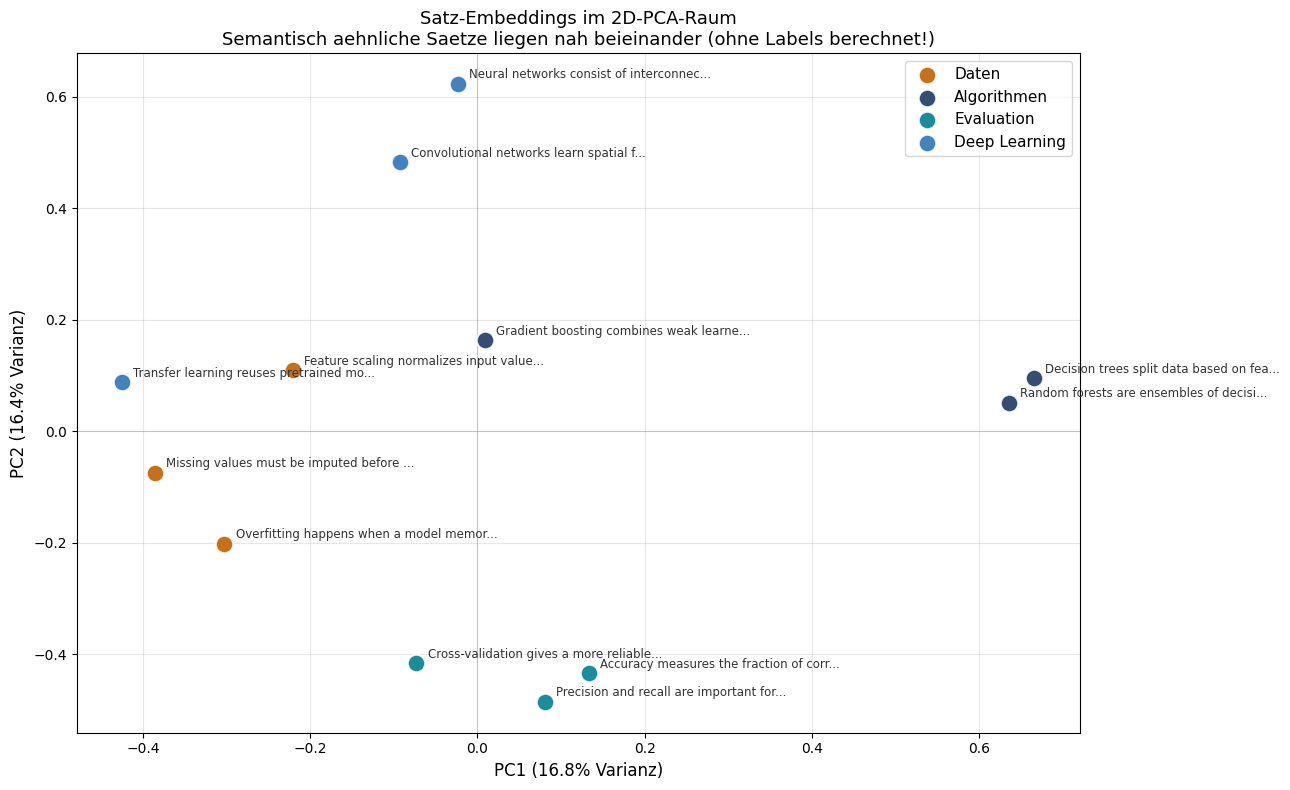

In [13]:
fig, ax = plt.subplots(figsize=(13, 8))

for kat in set(kategorien_labels):
    idxs = [i for i, k in enumerate(kategorien_labels) if k == kat]
    ax.scatter(vektoren_2d[idxs, 0], vektoren_2d[idxs, 1],
               label=kat, color=farben[kat], s=160, zorder=3, alpha=0.9,
               edgecolors="white", linewidth=1.5)

for i, satz in enumerate(saetze):
    kurz = satz[:38] + "..." if len(satz) > 38 else satz
    ax.annotate(kurz, (vektoren_2d[i, 0], vektoren_2d[i, 1]),
                textcoords="offset points", xytext=(8, 4),
                fontsize=8.5, color="#333333")

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} Varianz)", fontsize=12)
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} Varianz)", fontsize=12)
ax.set_title("Satz-Embeddings im 2D-PCA-Raum\n"
             "Semantisch aehnliche Saetze liegen nah beieinander "
             "(ohne Labels berechnet!)", fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.axhline(0, color="gray", linewidth=0.5, alpha=0.5)
ax.axvline(0, color="gray", linewidth=0.5, alpha=0.5)
plt.tight_layout()
plt.show()

# Schritt 17: Beobachtungsaufgabe – PCA-Visualisierung

## Aufgaben

1. Liegen gleichfarbige Punkte (gleiche Kategorie) tatsächlich näher zusammen?

2. Welche Sätze aus **verschiedenen Kategorien** liegen trotzdem nahe beieinander?
   Was haben sie semantisch gemeinsam?

3. Vergleich zu Kap. 12 (PCA auf Iris-Datensatz):
   Dort hatten wir **numerische Merkmale** als Input.
   Hier kommen die 384 Dimensionen aus einem Sprachmodell.
   Was ist das Gleiche, was ist anders?

4. Warum entstehen trotzdem Cluster, obwohl wir **keine Labels** zum
   Berechnen der Embeddings verwendet haben?

# ══════════════════════════════════════════════════════
# TEIL 4: K-Means auf Embeddings
# ══════════════════════════════════════════════════════

# Schritt 18: K-Means auf Embeddings – unüberwachtes Clustering

## Verbindung zu Kap. 11

In Kap. 11 haben wir K-Means auf numerischen Feature-Matrizen angewendet.
Hier ersetzen wir die Feature-Matrix durch **Embedding-Vektoren**.

Das Ziel: Findet K-Means die 4 Themengruppen **ohne** Labels?

**Adjusted Rand Index (ARI)** – Erinnerung aus Kap. 11:
- Misst, wie gut die gefundenen Cluster mit den wahren Labels übereinstimmen
- 1.0 = perfekte Übereinstimmung
- 0.0 = zufällige Zuordnung

In [14]:
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(vektoren)

kat_zu_zahl = {"Algorithmen": 0, "Evaluation": 1, "Deep Learning": 2, "Daten": 3}
wahre_labels = [kat_zu_zahl[k] for k in kategorien_labels]
ari = adjusted_rand_score(wahre_labels, cluster_labels)

print("K-Means Cluster-Zuordnung:")
print(f"{'Satz':<52} {'Cluster':>8}  {'Wahre Gruppe':<15}")
print("-" * 80)
for i, satz in enumerate(saetze):
    match = "✓" if cluster_labels[i] == wahre_labels[i] else " "
    print(f"  {satz[:50]:<52} Cluster {cluster_labels[i]}  {kategorien_labels[i]:<15} {match}")

print()
print(f"Adjusted Rand Index (ARI): {ari:.3f}")
print("(1.0 = perfekt, 0.0 = zufaellig)")
print()
if ari > 0.7:
    print("Ergebnis: K-Means findet die Themengruppen gut – dank aussagekraeftiger Embeddings.")
else:
    print("Ergebnis: Einige Gruppen werden verwechselt – Embeddings in 384D sind besser")
    print("          als in 2D (PCA verliert Information).")

K-Means Cluster-Zuordnung:
Satz                                                  Cluster  Wahre Gruppe   
--------------------------------------------------------------------------------
  Decision trees split data based on features.         Cluster 2  Algorithmen      
  Random forests are ensembles of decision trees.      Cluster 2  Algorithmen      
  Gradient boosting combines weak learners sequentia   Cluster 3  Algorithmen      
  Accuracy measures the fraction of correct predicti   Cluster 1  Evaluation      ✓
  Precision and recall are important for imbalanced    Cluster 1  Evaluation      ✓
  Cross-validation gives a more reliable model perfo   Cluster 1  Evaluation      ✓
  Neural networks consist of interconnected layers o   Cluster 0  Deep Learning    
  Convolutional networks learn spatial features in i   Cluster 0  Deep Learning    
  Transfer learning reuses pretrained model weights.   Cluster 3  Deep Learning    
  Feature scaling normalizes input values for better   Cl

# Schritt 19: Visualisierung – Wahre Labels vs. K-Means-Cluster

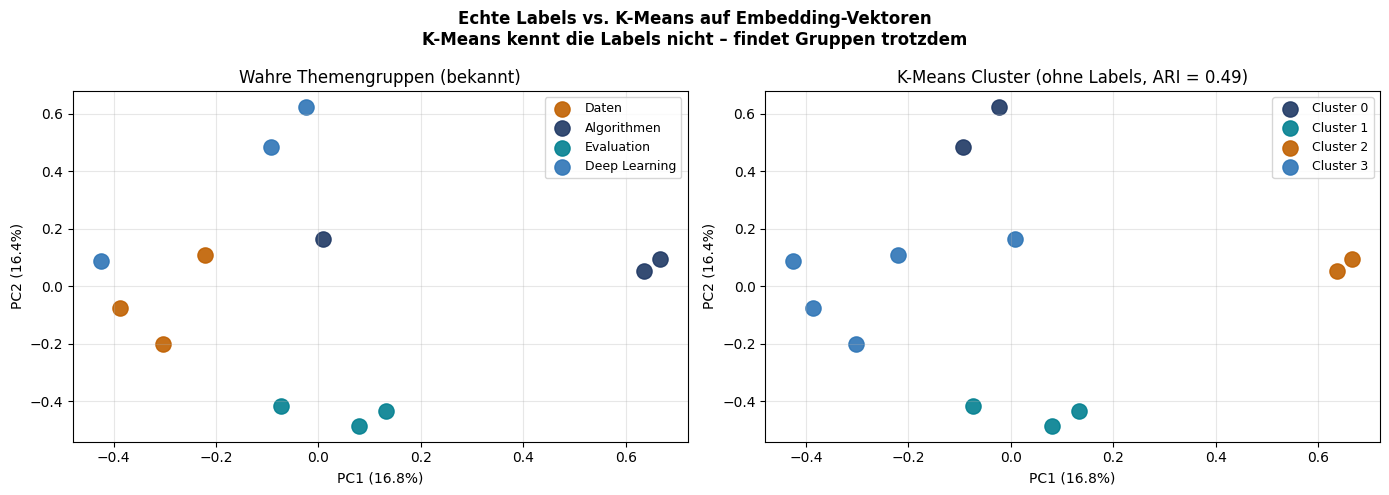

In [15]:
cluster_farben = ["#1F3864", "#028090", "#C06000", "#2E75B6"]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Links: wahre Labels
ax = axes[0]
for kat in set(kategorien_labels):
    idxs = [i for i, k in enumerate(kategorien_labels) if k == kat]
    ax.scatter(vektoren_2d[idxs, 0], vektoren_2d[idxs, 1],
               label=kat, color=farben[kat], s=120, alpha=0.9)
ax.set_title("Wahre Themengruppen (bekannt)", fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")

# Rechts: K-Means ohne Labels
ax = axes[1]
for c in range(k):
    idxs = [i for i, cl in enumerate(cluster_labels) if cl == c]
    ax.scatter(vektoren_2d[idxs, 0], vektoren_2d[idxs, 1],
               label=f"Cluster {c}", color=cluster_farben[c], s=120, alpha=0.9)
ax.set_title(f"K-Means Cluster (ohne Labels, ARI = {ari:.2f})", fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")

plt.suptitle("Echte Labels vs. K-Means auf Embedding-Vektoren\n"
             "K-Means kennt die Labels nicht – findet Gruppen trotzdem",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

# Schritt 20: Zusammenfassung

## Was haben wir gelernt?

| Schritt | Was wir getan haben | Verbindung zum Kurs |
|---------|--------------------|--------------------|
| **Bag-of-Words vs. Embedding** | Bedeutung vs. Wortzählung | Grundlage für alles |
| **Embedding berechnen** | Text → 384-dim Vektor | Kap. 3: Feature-Matrix X |
| **Kosinus-Ähnlichkeit** | Winkel zwischen Vektoren | Kap. 7: Distanzmaß bei k-NN |
| **Kontextuelle Embeddings** | „bank" (Geld) ≠ „bank" (Fluss) | Transformer, Self-Attention |
| **Semantische Suche** | Anfrage matchen ohne Stichwort-Match | Kap. 7: Nächste-Nachbarn |
| **PCA auf Embeddings** | 384D → 2D visualisieren | Kap. 12: Dimensionsreduktion |
| **K-Means auf Embeddings** | Cluster ohne Labels | Kap. 11: K-Means |

### Wissenstest

1. Warum ist ein Embedding-Vektor nützlicher als ein Bag-of-Words-Vektor?
2. Was misst die Kosinus-Ähnlichkeit – und was nicht?
3. Warum kann K-Means auf Embeddings Themengruppen finden, obwohl es keine Labels gibt?
4. Erklären Sie den Zusammenhang: Embeddings → PCA → Visualisierung in drei Sätzen.
5. Was ist der Unterschied zwischen statischen (Word2Vec) und kontextuellen (BERT) Embeddings?

### Weiterführend (optional)
- 3D-PCA: `PCA(n_components=3)` + Matplotlib 3D-Plot
- Mehrsprachiges Modell: `'paraphrase-multilingual-MiniLM-L12-v2'`
- Hugging Face MTEB Leaderboard: https://huggingface.co/spaces/mteb/leaderboard

# Schritt 21: Merksatz

## Merksatz

**LLMs „verstehen" Text, indem sie ihn in hochdimensionale Vektoren übersetzen –
alle ML-Werkzeuge des Kurses können direkt auf diese Vektoren angewendet werden.**

- Bag-of-Words zählt Wörter. Embeddings kodieren **Bedeutung und Kontext**.
- Kosinus-Ähnlichkeit misst den **Winkel** zwischen Vektoren – robust gegenüber Satzlänge.
- Semantische Suche ist k-NN im Embedding-Raum.
- PCA und K-Means funktionieren auf Embeddings genauso wie auf numerischen Features.
- Kontextuelle Embeddings lösen das Polysemie-Problem (Bank = Geld ≠ Bank = Fluss).
